torch.Size([3, 128, 128])


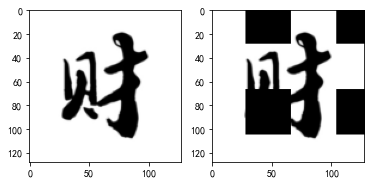

In [71]:
import torch
import numpy as np
import math
import PIL.Image as Image
import torchvision.transforms as T
import matplotlib.pyplot as plt

class Grid(object):
    def __init__(self, d1=2, d2=4, rotate=1, ratio=0.5, mode=1, prob=1.):
        self.d1 = d1
        self.d2 = d2
        self.rotate = rotate
        self.ratio = ratio # r
        self.mode = mode # reversed？
        self.st_prob = self.prob = prob # p

    def set_prob(self, epoch, max_epoch):
        self.prob = self.st_prob * min(1, epoch / max_epoch)

    def forward(self, img):
        if np.random.rand() > self.prob:
            return img
        h = img.size(1)
        w = img.size(2)

        # 1.5 * h, 1.5 * w works fine with the squared images
        # But with rectangular input, the mask might not be able to recover back to the input image shape
        # A square mask with edge length equal to the diagnoal of the input image 
        # will be able to cover all the image spot after the rotation. This is also the minimum square.
        hh = math.ceil((math.sqrt(h * h + w * w)))

        d = np.random.randint(self.d1, self.d2)
        # d = self.d

        # maybe use ceil? but i guess no big difference
        self.l = math.ceil(d * self.ratio)

        mask = np.ones((hh, hh), np.float32)
        st_h = np.random.randint(d)  # delta y
        st_w = np.random.randint(d)  # delta x
        for i in range(-1, hh // d + 1):
            s = d * i + st_h
            t = s + self.l
            s = max(min(s, hh), 0)
            t = max(min(t, hh), 0)
            mask[s:t, :] *= 0
        for i in range(-1, hh // d + 1):
            s = d * i + st_w
            t = s + self.l
            s = max(min(s, hh), 0)
            t = max(min(t, hh), 0)
            mask[:, s:t] *= 0
        r = np.random.randint(self.rotate)
        mask = Image.fromarray(np.uint8(mask))
        mask = mask.rotate(r)
        mask = np.asarray(mask)
        mask = mask[(hh - h) // 2:(hh - h) // 2 + h, (hh - w) // 2:(hh - w) // 2 + w] # 这里结合原理图方便看懂一些

        # mask = torch.from_numpy(mask).float().cuda()
        mask = torch.from_numpy(mask).float()
        if self.mode == 1:
            mask = 1 - mask

        mask = mask.expand_as(img)
        # img = img.cuda() * mask
        img = img * mask

        return img


if __name__ == "__main__":
    image = Image.open("/Volumes/wangzhaojiang/FLENet/data/augmentation/background/2.jpg").convert("RGB")
    tr = T.Compose([
        T.Resize((128,128)),
        T.ToTensor()
    ])
    x = tr(image)
    gridmask_image = Grid(d1=64, d2=96).forward(x)
    print(gridmask_image.shape)
    # print(gridmask_image.shape())
    fig, axs = plt.subplots(1,2)
    to_plot = lambda x: x.permute(1,2,0).cpu().numpy()
    axs[0].imshow(to_plot(x))
    axs[1].imshow(to_plot(gridmask_image))
    plt.show()


In [ ]:
import random

def add_sp_noise(image, prob=0.2):
        data = np.asarray(image)
        shape = data.shape
        noise = np.random.random(shape)  # 生成随机值
        data[noise < prob] = 0  # 小于 probability 的随机数代表黑色斑点
        data[noise > 1 - prob] = 255  # 大于 1-probability 的随机数代表白色斑点
        return Image.fromarray(data)

def process_image_in_chunks_with_noise(image_path, w, h):
    chunks = []
    with Image.open(image_path) as img:
        img = img.resize((256, 256))
        width, height = img.size
        chunk_width = width // w
        chunk_height = height // h
        for i in range(h):
            top = i * chunk_height
            bottom = (i + 1) * chunk_height if i < h - 1 else height
            for j in range(w):
                left = j * chunk_width
                right = (j + 1) * chunk_width if j < w - 1 else width
                chunk = (left, top, right, bottom)
                chunks.append(chunk)

        chunk_images = []
        for chunk in chunks:
            prob = round(random.uniform(0, 0.5), 2)
            chunk_image = add_sp_noise(img.crop(chunk), prob)
            chunk_images.append(chunk_image)

        # 将处理后的图像块组合成一个完整的图像
        # print(len(chunk_images))
        result = Image.new(img.mode, (width, height))
        for i, chunk_image in enumerate(chunk_images):
            left = (i % w) * chunk_width
            right = ((i % w) + 1) * chunk_width if (i % w) < w - 1 else width
            top = (i // w) * chunk_height
            bottom = ((i // w) + 1) * chunk_height if (i // w) < h - 1 else height
            result.paste(chunk_image, (left, top, right, bottom))

    # 返回完整的处理后的图像
    return result


def main():
    image_path = "/Volumes/wangzhaojiang/FLENet/data/augmentation/background/2.jpg"
    w = 4
    h = 4
    original_image = Image.open(image_path)
    noisy_image = process_image_in_chunks_with_noise(image_path, w, h)
    original_image.show()
    noisy_image.show()

if __name__ == '__main__':
    main()

In [17]:
from concurrent.futures import ThreadPoolExecutor
import random
import numpy as np
from PIL import Image

# 生成椒盐噪声
def salt_and_pepper_noise(prob, shape):
    noise = np.zeros(shape, dtype=np.uint8)
    for i in range(shape[0]):
        for j in range(shape[1]):
            if np.random.random() < prob:
                noise[i][j] = 0
            elif np.random.random() > 1 - prob:
                noise[i][j] = 255
    return noise

# 生成高斯噪声
def gaussian_noise(mu, sigma, shape):
    return (np.random.normal(loc=mu, scale=sigma, size=shape))

# 添加噪声到图像中
def add_noise(image):
    # 随机选取一种噪声类型进行添加（这里只示范了椒盐噪声和高斯噪声两种）
    noise_type = random.choice(['salt_and_pepper', 'gaussian'])
    if noise_type == 'salt_and_pepper':
        prob = 0.05 # 椒盐噪声的比例
        shape = (image.size[1], image.size[0]) # 矩阵转置
        noisy_data = salt_and_pepper_noise(prob, shape)
    elif noise_type == 'gaussian':
        mu, sigma = 0, 20 # 均值和方差
        shape = (image.size[1], image.size[0], image.getbands().__len__())
        noisy_data = gaussian_noise(mu, sigma, shape)

    noisy_image = Image.fromarray(noisy_data)
    # 调整噪声图像的尺寸与原图像匹配
    noisy_image = noisy_image.resize((image.width, image.height), resample=Image.BILINEAR)
    # 将噪声图像的通道数调整为与原图相同
    # noisy_image.putalpha(255)
    noisy_image = noisy_image.convert(image.mode)
    # 将原图和噪声图叠加产生混合的图像
    mixed_image = Image.blend(image, noisy_image, 0.5)
    print(type(mixed_image))

    return mixed_image

# 添加斑点噪声到图像中
def add_sp_noise(image, prob=0.2):
    data = np.asarray(image)
    shape = data.shape
    noise = np.random.random(shape) # 生成随机值
    data[noise < prob] = 0 # 小于 probability 的随机数代表黑色斑点
    data[noise > 1 - prob] = 255 # 大于 1-probability 的随机数代表白色斑点
    return Image.fromarray(data)

# 添加块状斑点噪声到图像中（黑白取反）
def add_block_sp_noise(image, num_blocks=14):
    data = np.asarray(image)
    shape = data.shape
    for _ in range(num_blocks):
        x = random.randint(0, shape[1] - 1) # 获取实际图片的宽度
        y = random.randint(0, shape[0] - 1) # 获取实际图片的高度
        x_len = random.randint(5, int(shape[1] / 4))
        y_len = random.randint(5, int(shape[0] / 4))
        if random.randint(0, 1) == 1:
            data[y:y+y_len, x:x+x_len] = 255 - data[y:y+y_len, x:x+x_len] # 反转像素值
    return Image.fromarray(data)

# 分块处理图像并行添加噪声
def process_image_in_chunks_with_noise(img, w, h):
    chunks = []
    
    width, height = img.size
    chunk_width = width // w
    chunk_height = height // h
    for i in range(h):
        top = i * chunk_height
        bottom = (i + 1) * chunk_height if i < h - 1 else height
        for j in range(w):
            left = j * chunk_width
            right = (j + 1) * chunk_width if j < w - 1 else width
            chunk = (left, top, right, bottom)
            chunks.append(chunk)
    chunk_images = []
    for chunk in chunks:
        prob = round(random.uniform(0, 0.1), 2)
        chunk_images.append(add_sp_noise(img.crop(chunk),prob))

        # 将处理后的图像块组合成一个完整的图像
        
        result = Image.new(img.mode, (width, height))
        for i, chunk_image in enumerate(chunk_images):
            left = (i % w) * chunk_width
            right = ((i % w) + 1) * chunk_width if (i % w) < w - 1 else width
            top = (i // w) * chunk_height
            bottom = ((i // w) + 1) * chunk_height if (i // w) < h - 1 else height
            result.paste(chunk_image, (left, top, right, bottom))

    # 返回完整的处理后的图像
    return result
img = Image.open('/Volumes/wangzhaojiang/FLENet/data/augmentation/background/25.png').convert('L')

result = process_image_in_chunks_with_noise(img, w=4, h=4)
result.show()
result.save('noise7.jpg')

编写一个数据增强类，这个数据增强方式主要模拟自然环境中对一张图片的磨损和侵蚀。这个类的预定义参数为原始图片大小和小块大小，数据增强方式为将图片分成多个小方块